In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# data preprocessing

In [4]:
# handle missing value

df["Income"] = df["Income"].fillna(df["Income"].median())

# Feature engineering


In [5]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [6]:
# Age
df["Age"] = 2026-df["Year_Birth"]

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [8]:
# joining
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
reference_date = df["Dt_Customer"].max()   #we use max because we want same data very time when we run .that why we dont use datetime


df["customer_tenure_days"] = (reference_date -df["Dt_Customer"]).dt.days

In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days'],
      dtype='object')

In [10]:
# spending
df["total_spending"] = df["MntMeatProducts"] +df["MntFishProducts"] +df["MntSweetProducts"] +df["MntGoldProds"] +df["MntWines"] +df["MntFruits"]

In [11]:
#children
df["total_children"] = df["Kidhome"] +df["Teenhome"]

In [12]:
#Education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate" , "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "PhD":"Postgraduate", "Master":"Postgraduate"
})
    
    

In [13]:
# marital status
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Together" , "Together":"Together",
    "Single":"Alone",
    "Divorced":"Alone", "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

In [14]:
df["Living_With"].value_counts()


Living_With
Together    1444
Alone        796
Name: count, dtype: int64

# drop columns

In [15]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'total_spending',
       'total_children', 'Living_With'],
      dtype='object')

In [16]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols +spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [17]:
df_cleaned.shape

(2240, 15)

In [18]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'total_spending',
       'total_children', 'Living_With'],
      dtype='object')

# Outlier

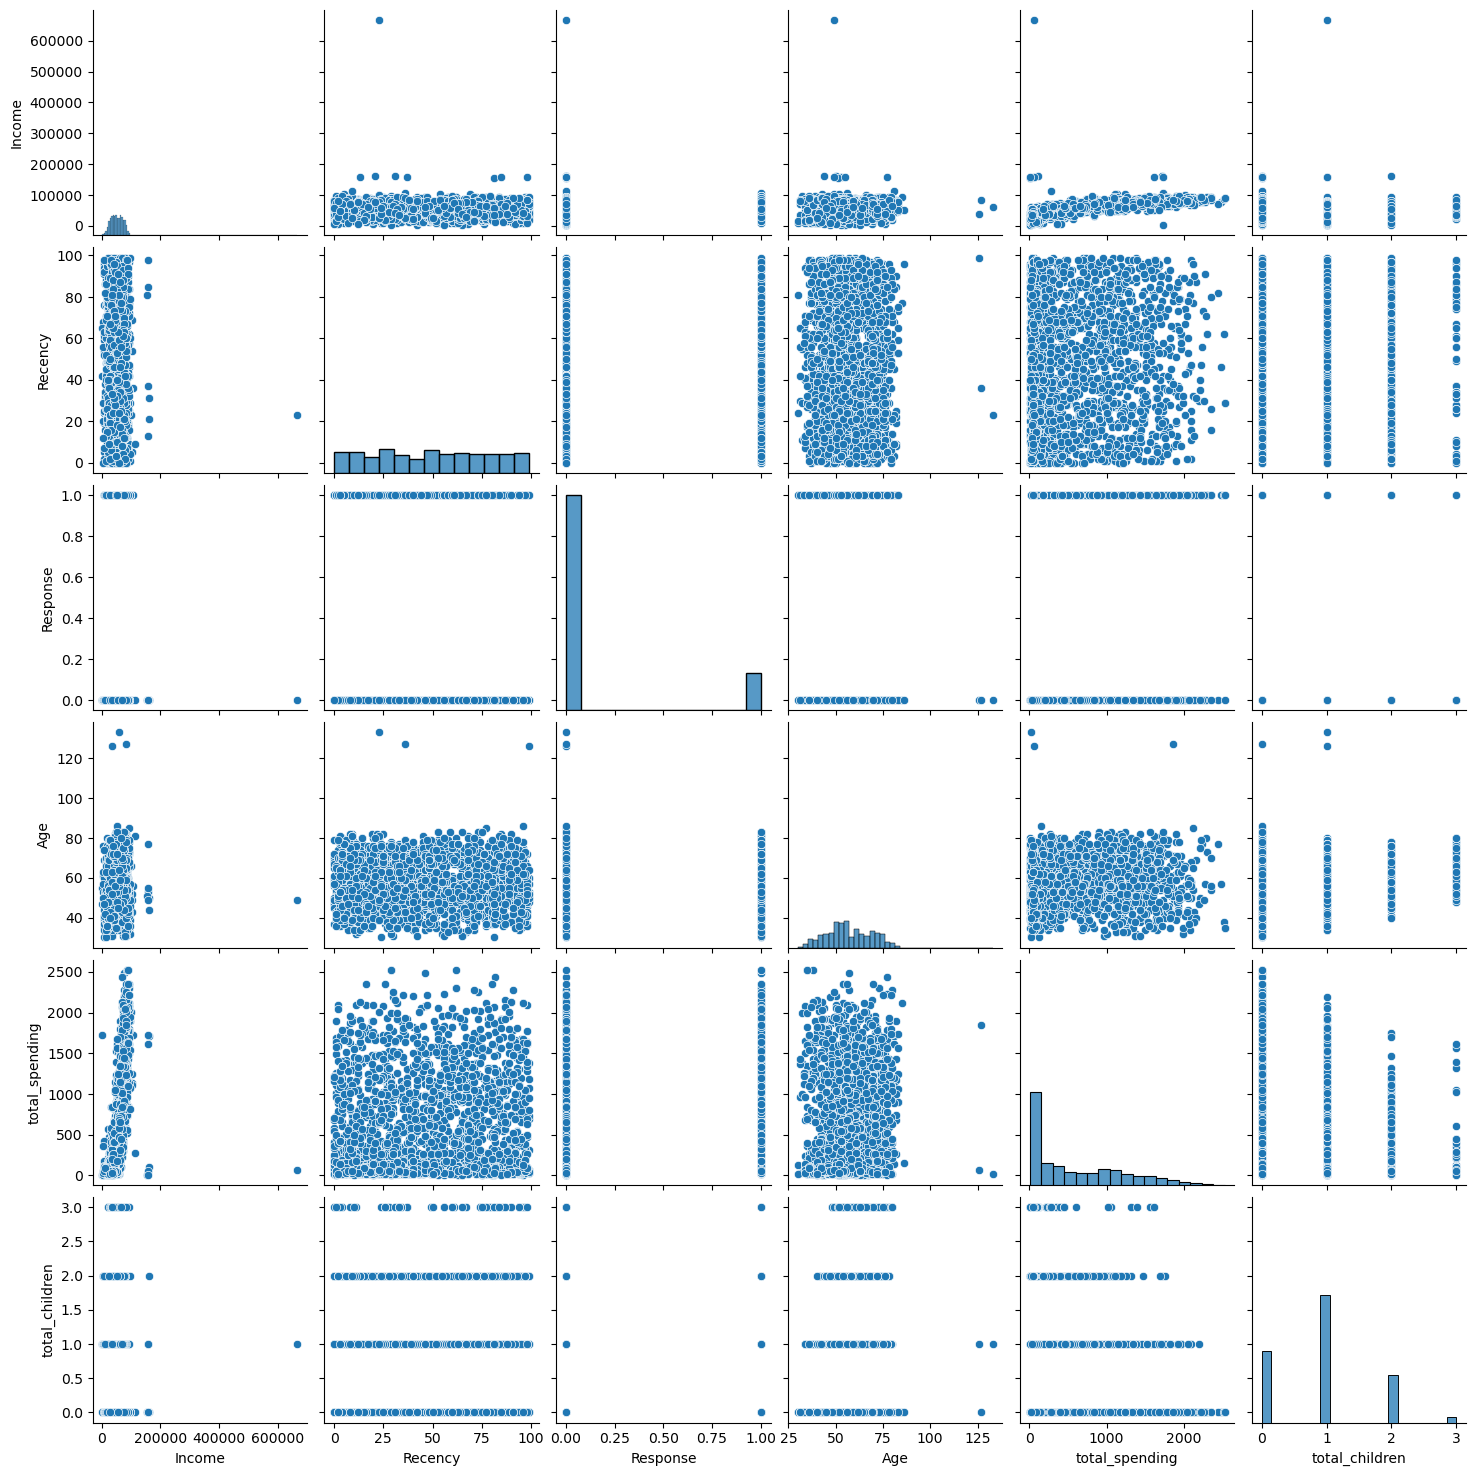

In [19]:
cols = ["Income","Recency","Response","Age","total_spending","total_children"]

#relative plots of some feature -> pair plots
sns.pairplot(df_cleaned[cols])

In [20]:
# Remove outlier
print("print data size with outlier :",len(df_cleaned))

df_cleaned =  df_cleaned[(df_cleaned["Age"] <90) ]
df_cleaned =  df_cleaned[(df_cleaned["Income"] <600_000) ]

print("print data size without  outlier :",len(df_cleaned))


print data size with outlier : 2240
print data size without  outlier : 2236


# Heatmap

In [21]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

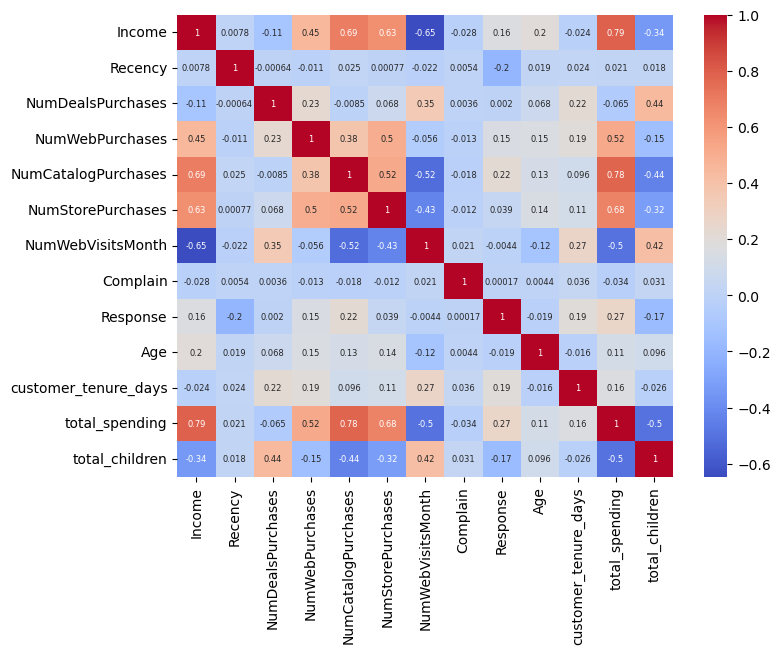

In [22]:
plt.figure(figsize =(8,6))

sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

# Encoding

In [23]:
from sklearn.preprocessing import OneHotEncoder


In [24]:
ohe = OneHotEncoder()

cat_cols = ["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [25]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

In [26]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df],axis =1)

In [27]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Together
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [28]:
from sklearn.preprocessing import StandardScaler


In [29]:
X = df_encoded

In [30]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

In [32]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

In [33]:
#plt.scatter(X_pca[:,0], X_pca[:,1])  for 2d

Text(0.5, 0.92, '3d projection')

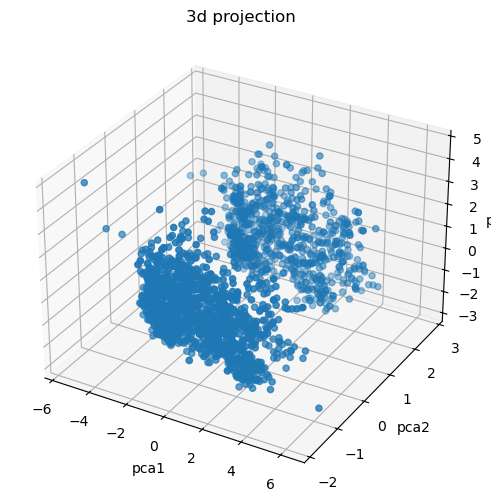

In [34]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection = "3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:, 2])

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3d projection")

In [35]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analze K value

# 1.Elbow method

In [36]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss =[]

for k in range(1,11):
    kmeans = KMeans(n_clusters = k,random_state =42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [37]:
knee = KneeLocator(range(1,11), wcss, curve ="convex", direction = "decreasing")
optimal_k = knee.elbow

In [38]:
print("optimal k value:",optimal_k)

optimal k value: 4


Text(0, 0.5, 'wcss')

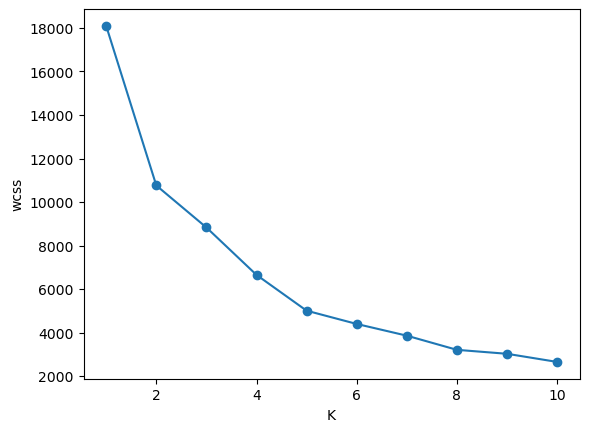

In [39]:
# Plot
plt.plot(range(1,11), wcss ,marker ='o')
plt.xlabel("K")
plt.ylabel("wcss")

# Silhouette Methos

In [45]:
from sklearn.metrics import silhouette_score
import pandas as pd
scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters = k,random_state =42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)
    

Text(0, 0.5, 'silhouette score')

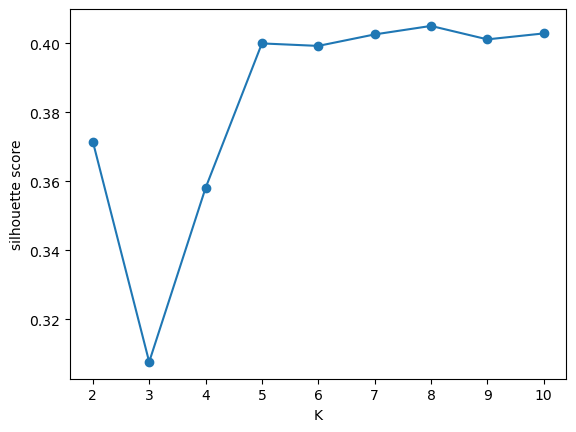

In [49]:
# Plot
plt.plot(range(2, 11), scores ,marker ='o')
plt.xlabel("K")
plt.ylabel("silhouette score")

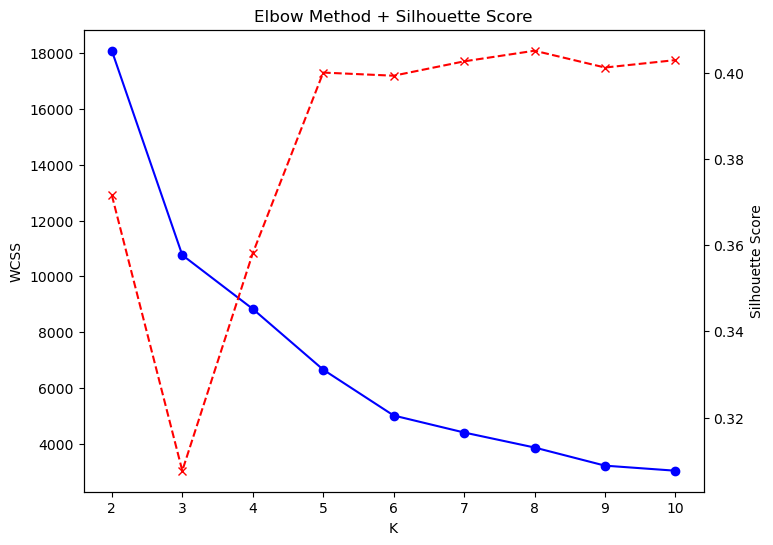

In [50]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("Silhouette Score")

plt.title("Elbow Method + Silhouette Score")
plt.show()

# Clustering

In [51]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

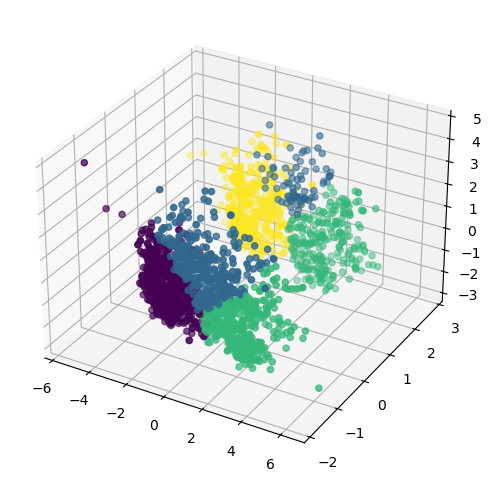

In [52]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [53]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [54]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

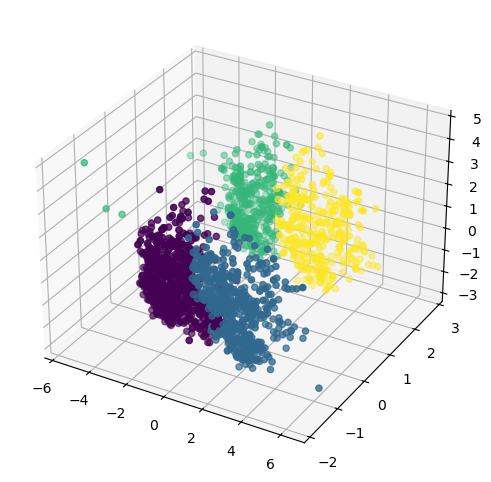

In [55]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

# Characterization of Clusters

In [56]:

X["cluster"] = labels_agg

In [57]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Together,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

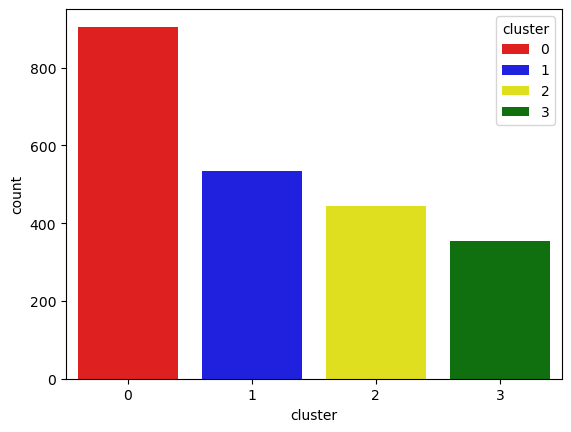

In [58]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

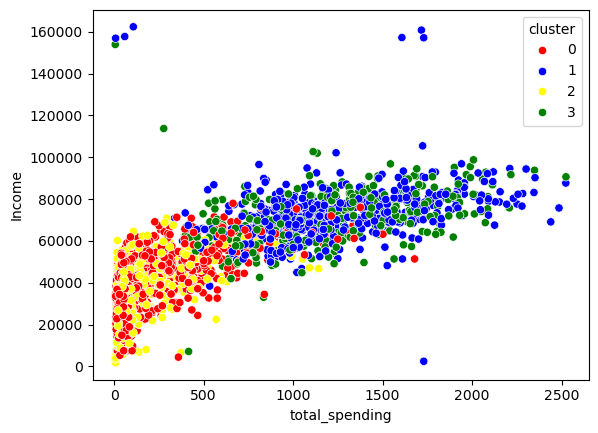

In [60]:
# Income & Spending patterns

sns.scatterplot(x=X["total_spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [ ]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)